## Problem 3 (28 points): Extended Kalman Filter
**Goal of this problem**: In lecture 12, we learned about the conventional Kalman filter (KF) and the importance of Q and R.
In this problem, students will learn to expand beyond the KF to account for nonlinearities in many real-world dynamical systems.
Furthermore, students will see the importance of Q and R firsthand.

First, briefly revisit the assumptions for WLS from problem 2 on homework 2.
For a system without dynamics (i.e., not moving), the Kalman Filters can be considered recursive least squares estimation.
So, we inherit the assumptions from least squares but can now process measurements through time.
As before, the error could be non-spherical or correlated.
We would need to account for these in our measurement covariance $R$.
The ideal weighting matrix $W$ in weighted or generalized least squares (WLS and GLS) and the ideal measurement covariance matrix used in the Kalman Filter are related by $R = W^{-1}$.
Intuitively, high variance means we want a lower weight.

However, most systems have dynamics.
We must account for the system dynamics when processing measurements through time.
Unlike least squares, the Kalman Filter leverages the dynamics[^1] to improve our localization.
However, vehicle dynamics are often *nonlinear*.
The conventional Kalman filter (KF) cannot handle nonlinearity.
So, we will leverage our insights from linearization that we used for Newton-Raphson to build up the *extended* Kalman filter (EKF)[^2], which will allow us to have more general, *nonlinear* functions for our dynamics and measurement models.

Let us consider a simple 2D car scenario.
Let the state of the vehicle $\mu_t$ be defined as:
$$
\mu_t := \begin{bmatrix} x_{t} & y_{t} & \theta_t \end{bmatrix}^\top,
$$
where $x_t$ is the x-position of the ground vehicle, $y_t$ is its y-position, and $\theta_t$ is its orientation **in radians**.
We will also consider a control vector $u_t$, which governs how our ground vehicle moves with time:
$$
u_t := \begin{bmatrix} s_t & \alpha_t \end{bmatrix}^\top
$$
where $s_t$ represents the vehicle's forward speed, in meters per second, and $\alpha_t$ represents its angular rate, **in radians per second**.
Let our *noisy* state transition of the ground vehicle be represented as the following *nonlinear* function:
$$
\begin{aligned}
\mu_t &= f(\mu_{t-1}, u_{t}) + w_t, \\
&= \underbrace{\mu_{t-1} + \Delta t \begin{bmatrix} s_{t} \cos(\theta_{t-1}) \\ s_{t} \sin(\theta_{t-1}) \\ \alpha_{t} \end{bmatrix}}_{f(\mu_{t-1}, u_{t})} + w_t,
\end{aligned}
$$
where $f$ is the state transition model function (i.e., our dynamics model), $\Delta t$ is the time in seconds between consecutive state estimates and $w_t$ represents the state transition noise, which is assumed to be Gaussian such that $w_t \sim \mathcal{N}(0, Q)$, just like our assumptions in lecture.
Note that, unlike the state $\mu_t$ and the state transition noise $w_t$, the control $u_t$ is *not* a random variable.
This is because we know what control we provide to the system, since we choose our vehicle's forward speed and angular rate.

For our measurements, we will consider ranging measurements from 4 stationary 2D beacons.
Thus, we can represent our (*nonlinear*) ranging measurement[^3] with respect to beacon $i$ as:
$$
h^{(i)}(\mu_t) = \sqrt{(x^{(i)} - x_t)^2 + (y^{(i)} - y_t)^2},
$$
where $\left(x^{(i)}, y^{(i)}\right)$ represents the known 2D position of the $i^{th}$ stationary beacon.
And we can thus represent our nonlinear measurement model as:
$$
\begin{aligned}
    z_t &= h(\mu_t) + v_t, \\
    h(\mu_t) &:= \begin{bmatrix} h^{(1)}(\mu_t) & h^{(2)}(\mu_t) & h^{(3)}(\mu_t) & h^{(4)}(\mu_t) \end{bmatrix}^\top,
\end{aligned}
$$
where $z_t$ represents our received measurement vector, $h(\mu_t)$ represents our expected measurement vector at state $\mu_t$, and $v_t$ represents our measurement noise, which is assumed to be Gaussian such that $v_t \sim \mathcal{N}(0, R)$, just like our assumptions in lecture.
Note that our received measurement $z_t \in \mathbb{R}^4$, since we receive four ranging measurements (one from each stationary beacon).
We can now write the EKF equations below.

### Predict:
$$
\begin{aligned}
    \hat{\mu}_{t|t-1} &= f\left(\hat{\mu}_{t-1|t-1}, u_{t}\right), & \text{Predict the next state from dynamics}\\
    P_{t|t-1} &= F_t P_{t-1|t-1} F_t^\top + Q, & \text{Predict the next covariance from dynamics}
\end{aligned}
$$
where $F_t$ is the linearized state transition matrix, defined as $F_t := \left. \dfrac{\partial f}{\partial \mu} \right|_{\hat{\mu}_{t-1|t-1}, u_{t}}$.
### Update:
$$
\begin{aligned}
\tilde{y}_{t} &= z_t - h\left(\hat{\mu}_{t|t-1} \right), & \text{Measured vs theoretical ranges}\\
K_t &= P_{t|t-1} H_t^\top \left( R + H_t P_{t|t-1} H_t^\top \right)^{-1}, & \text{Measurement vs. dynamics weighting} \\
\hat{\mu}_{t|t} &= \hat{\mu}_{t|t-1} + K_t \tilde{y}_t, & \text{Update the state from measurements} \\
P_{t|t} &= (I - K_t H_t) P_{t|t-1}, & \text{Update the covariance from measurements}
\end{aligned}
$$
where $H_t$ is the linearized measurement matrix, defined as $H_t := \left. \dfrac{\partial h}{\partial \mu} \right|_{\hat{\mu}_{t|t-1}}$.

Indeed, the expressions of the EKF are very similar to the standard KF, except we use our nonlinear motion model and measurement model directly in equations (3) and (4), and we use linearizations of our motion model and measurement model for the $F_t$ and $H_t$ matrices.

### 3.1 Jacobain for Dynamics [2 points]

Find the Jacobian $F_t$ for your EKF.

*Hint:* This Jacobian $F_t\in\mathbb{R}^{3 \times 3}$ will be defined as:
$$
\begin{aligned}
    F_t &:= \left. \frac{\partial f}{\partial \mu} \right|_{\hat{\mu}_{t-1|t-1}, u_{t}}, \\
    &= \left. \begin{bmatrix} \dfrac{\partial f_1}{\partial x} & \dfrac{\partial f_1}{\partial y} & \dfrac{\partial f_1}{\partial \theta} \\ \\
    \dfrac{\partial f_2}{\partial x} & \dfrac{\partial f_2}{\partial y} & \dfrac{\partial f_2}{\partial \theta} \\ \\
    \dfrac{\partial f_3}{\partial x} & \dfrac{\partial f_3}{\partial y} & \dfrac{\partial f_3}{\partial \theta}
    \end{bmatrix} \right|_{\hat{\mu}_{t-1|t-1}, u_{t}}
\end{aligned}
$$
Note, this notation indicates that, after taking the matrix derivative, you will evaluate $F_t$ at $\mu = \hat{\mu}_{t-1|t-1}$ and $u = u_{t}$.
Make sure to include the subscripts!

*Note:* You can check your work with Wolfram Alpha, Mathematica, or Matlab, but you must show your derivation.

***ANSWER***

<!-- $$
\begin{aligned}
f_1 &= x \\
f_2 &= y \\
f_3 &= \theta = tan(\frac{y}{x})
\end{aligned}
$$

$$
\begin{aligned}
    F_t &:= \left. \frac{\partial f}{\partial \mu} \right|_{\hat{\mu}_{t-1|t-1}, u_{t}}, \\
    &= \left. \begin{bmatrix} \dfrac{\partial f_1}{\partial x} & \dfrac{\partial f_1}{\partial y} & \dfrac{\partial f_1}{\partial \theta} \\ \\
    \dfrac{\partial f_2}{\partial x} & \dfrac{\partial f_2}{\partial y} & \dfrac{\partial f_2}{\partial \theta} \\ \\
    \dfrac{\partial f_3}{\partial x} & \dfrac{\partial f_3}{\partial y} & \dfrac{\partial f_3}{\partial \theta}
    \end{bmatrix} \right|_{\hat{\mu}_{t-1|t-1}, u_{t}}. \\
    &= \left. \begin{bmatrix} 1 & 0 & 0 \\ \\
    0 & 1 & 0  \\
    -\frac{y}{x^2}sec^2(\frac{y}{x}) & (\frac{1}{x})sec^2(\frac{y}{x}) & 1
    \end{bmatrix} \right|_{\hat{\mu}_{t-1|t-1}, u_{t}}. \\
\end{aligned}
$$ -->

<!-- \mu_t &=  -->
$$
\begin{aligned}
f(\mu_{t-1}, u_{t}) &= \mu_{t-1} + \Delta t \begin{bmatrix} s_{t} \cos(\theta_{t-1}) \\ s_{t} \sin(\theta_{t-1}) \\ \alpha_{t} \end{bmatrix} \\
&= \begin{bmatrix} x_{t-1} \\ y_{t-1} \\ \theta_{t-1} \end{bmatrix} + \Delta t \begin{bmatrix} s_{t} \cos(\theta_{t-1}) \\ s_{t} \sin(\theta_{t-1}) \\ \alpha_{t} \end{bmatrix} \\
\end{aligned}
$$

<br/><br/>
$$
\begin{aligned}
F_t &= \begin{bmatrix} 1 & 0 & -\Delta t\ s_t sin(\theta_{t-1}) \\
    0 & 1 & \Delta t\ s_t cos(\theta_{t-1}) \\
    0 & 0 & 1 \end{bmatrix}
\end{aligned}
$$

### 3.2 Jacobian for Measurment Function [2 points]

Find the Jacobian $H_t$ for your EKF.
Let $(x^{(i)}, y^{(i)})$ represent the position of the $i^{th}$ beacon and consider that we have four beacons (and their corresponding ranging measurements) available at all times.

*Hint:* This Jacobian $H_t\in\mathbb{R}^{4 \times 3}$ and will be defined as:
$$
\begin{aligned}
    H_{t} &:= \left. \frac{\partial h}{\partial \mu} \right|_{\mu=\hat{\mu}_{t|t-1}}, \\
    &= \left. \begin{bmatrix} \dfrac{\partial h_1}{\partial x} & \dfrac{\partial h_1}{\partial y} & \dfrac{\partial h_1}{\partial \theta} \\
    & \vdots & \\
    \dfrac{\partial h_4}{\partial x} & \dfrac{\partial h_4}{\partial y} & \dfrac{\partial h_4}{\partial \theta}
    \end{bmatrix} \right|_{\hat{\mu}_{t|t-1}}.
\end{aligned}
$$
Note, after taking the derivative, you will evaluate $H_t$ at $\mu = \hat{\mu}_{t|t-1}$ which is the *predicted* state (our state estimate after the predict step).

*Note:* You can check your work with Wolfram Alpha, Mathematica, or Matlab, but you must show your derivation.

***ANSWER***

$$
h^{(i)}(\mu_t) = \sqrt{(x^{(i)} - x_t)^2 + (y^{(i)} - y_t)^2}
$$

<br/><br/>

$$
\begin{aligned}
H_t &= \begin{bmatrix}
\frac{2(x^1 - x_t)(-1)}{2 \sqrt{(x^1 - x_t)^2 + (y^1 - y_t)^2}} &
\frac{2(y^1 - y_t)(-1)}{2 \sqrt{(x^1 - x_t)^2 + (y^1 - y_t)^2}} &
0 \\
& \vdots & \\
\frac{2(x^4 - x_t)(-1)}{2 \sqrt{(x^4 - x_t)^2 + (y^4 - y_t)^2}} &
\frac{2(y^4 - y_t)(-1)}{2 \sqrt{(x^4 - x_t)^2 + (y^4 - y_t)^2}} &
0 \\
\end{bmatrix} \\ \\
&= \begin{bmatrix}
\frac{-(x^1 - x_t)}{\sqrt{(x^1 - x_t)^2 + (y^1 - y_t)^2}} &
\frac{-(y^1 - y_t)}{\sqrt{(x^1 - x_t)^2 + (y^1 - y_t)^2}} &
0 \\
& \vdots & \\
\frac{-(x^4 - x_t)}{\sqrt{(x^4 - x_t)^2 + (y^4 - y_t)^2}} &
\frac{-(y^4 - y_t)}{\sqrt{(x^4 - x_t)^2 + (y^4 - y_t)^2}} &
0 \\
\end{bmatrix} \\
\end{aligned}
$$


### 3.3 True State Dynamics [3 points]
Let us first simulate the *true* state dynamics $\mu_t$.
Create a function called
`simulate_noisy_state_trans(mu_cur, u_cur, Q)`, which takes in the current true state `mu_cur` ,control `u_cur`, process noise `Q`, and  outputs the propagated state by following the nonlinear state propagation model defined in Eq. (1).
Initialize the true initial state as $\mu_0=\begin{bmatrix} 0 & 0 & 0 \end{bmatrix}^\top$ and let the state process noise covariance $Q = \text{diag}([0.1, 0.1, \mathbf{0.01}])$ (Note that the process noise for the orientation is different!).
Define the control vector $u_t$ with a constant speed of $s_t = 5$ meters per second and a constant angular rate $\alpha_t = 0.1$ radians per second for all time steps $t$.

Plot the simulated true state trajectory, using the provided plot function. Also, check your implementation in autograder.

*Hint 1:* First create a function `state_trans_mdl(mu_cur, u_cur)` which represents the state transition model function $f(\cdot)$ and does *not* inject noise.
Then your `simulate_noisy_state_trans` function can call this function and inject noise according to the covariance matrix $Q$.
This may also be helpful when you implement your EKF in part (7) since your EKF will need to evaluate $f(\cdot)$ in the predict step (see Eq. 3).

*Hint 2: If a car is moving *with no noise* at a constant speed of $s_t = 5$ meters per second and a constant angular rate $\alpha_t = 0.1$ radians per second, what shape would you expect it to make? What is the radius of this shape? Make sure you add different noise at each timestep!*

*Note:* A diagonal covariance matrix means the noise added to $x_t$, $y_t$, and $\theta_t$ are *uncorrelated*.
For a joint Gaussian, this also means that the noise added is independent of each other.
Moreover, the noise must be independent of any part $x_t$, $y_t$, or $\theta_t$ of the state $\mu_t$.
The measurements below have a similar theoretical basis.

***ANSWER***

[Submit code to autograder (2 points)]

[Provide 4 plots for different runs (1 point)]

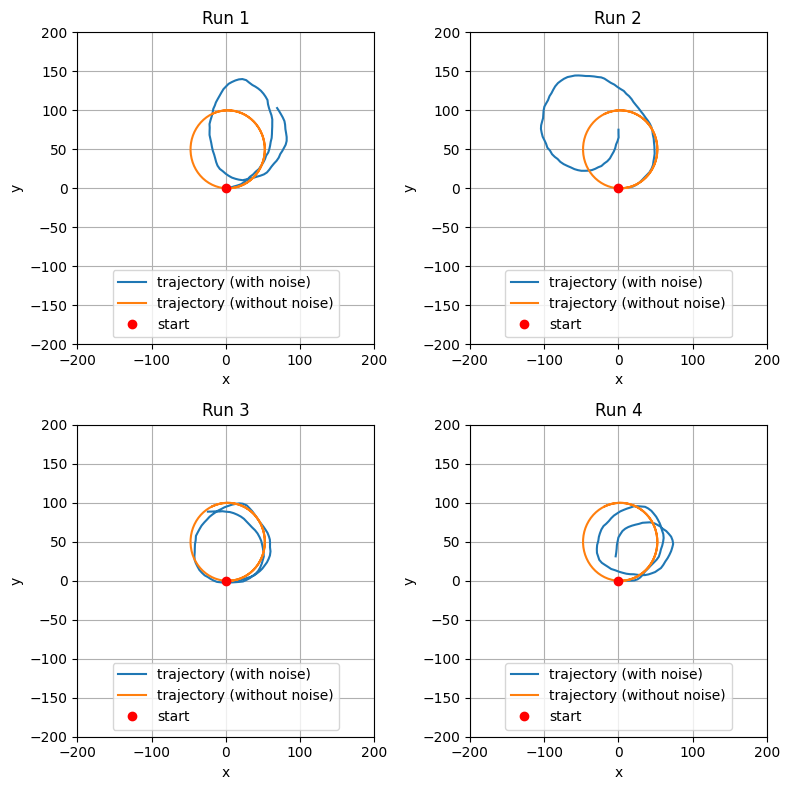

In [1]:
# @title
import numpy as np
import matplotlib.pyplot as plt

# constants (do not change)
def setup_environment():
    delta_t = 1  # time step
    Q = np.diag(np.array([0.1, 0.1, 0.01]))  # process noise covariance
    R = 10 * np.eye(4)  # measurement noise covariance
    seed = 0   # random seed for reproducibility (do not change!!!)
    lent = 100 # length of trajectory
    n_mc = 4   # number of Monte Carlo simulations
    mu0 = np.array([0, 0, 0])  # initial state [s_0, alpha, theta]

    # control input
    st = 5   # speed
    alpha = 0.1  # angular rate
    u_cur = np.array([st, alpha]) # current control input (2x1) [s_t, alpha]

    # set random seed
    np.random.seed(seed)

    env = {
        'delta_t': delta_t,
        'Q': Q,
        'R': R,
        'lent': lent,
        'n_mc': n_mc,
        'mu0': mu0,
        'u_cur': u_cur,
        'seed': seed
    }

    return env

# nominal model
def state_trans_mdl(mu_cur, u_cur):
    """
    Nominal state transition model
        Inputs:
            mu_cur: current state mean (3,) [s_t, alpha, theta]
            u_cur: current control input (2,) [s_t, alpha]
        Outputs:
            mu_next: next state mean (3,) [s_t+1, alpha, theta]
    """
    # *****************************************************************
    # State Transition Model  ******************************************
    # *****************************************************************
    # TODO: replace with correct state transition model
    delta_t = 1

    s_t, alpha = u_cur

    mu_next = mu_cur + delta_t * np.array([s_t * np.cos(mu_cur[2]), s_t * np.sin(mu_cur[2]), alpha])

    return mu_next



    # *****************************************************************
    # *****************************************************************

    return mu_next

# noisy dynamics
def simulate_noisy_state_trans(mu_cur, u_cur, Q):
    """
    Simulate noisy state transition
    Inputs:
        mu_cur: current state mean (3,) [s_t, alpha, theta]
        u_cur: current control input (2,) [s_t, alpha]
        Q: process noise covariance (3x3)
    Outputs:
        mu_next: next state mean (3x1) [s_t+1, alpha
    """
    noise = np.random.multivariate_normal(np.zeros(3), Q)

    # *****************************************************************
    # State Transition Model with Noise  ******************************
    # *****************************************************************
    # TODO: implement the state transition with process noise (use noise above)
    mu_next = state_trans_mdl(mu_cur, u_cur) + noise

    # *****************************************************************
    # *****************************************************************

    return mu_next

# generate trajectories
def simulate_trajectories(env):
    """
    Simulate multiple trajectories with and without noise
    Outputs:
        mu_true: true trajectory with noise (3 x lent x n_mc)
        mu_nonoise: trajectory without noise (3 x lent)
    """
    lent = env['lent']
    n_mc = env['n_mc']
    u_cur = env['u_cur']
    Q = env['Q']
    mu0 = env['mu0']
    seed = env['seed']

    np.random.seed(seed)

    mu_true = np.zeros((3, lent, n_mc))      # true trajectory with noise
    mu_nonoise = np.zeros((3, lent))          # trajectory without noise

    # simulate no-noise trajectory
    for i in range(1, lent):
        mu_cur = mu_nonoise[:, i - 1]
        mu_next = state_trans_mdl(mu_cur, u_cur)
        mu_nonoise[:, i] = mu_next

    # simulate noisy trajectory
    for mci in range(4):
        mu_true[:, 0, mci] = mu0

        for i in range(1, lent):
            mu_cur = mu_true[:, i - 1, mci]
            mu_next = simulate_noisy_state_trans(mu_cur, u_cur, Q)
            mu_true[:, i, mci] = mu_next


    return mu_true, mu_nonoise


def plot_trajectories(mu_true, mu_nonoise, n_mc):
    """
    Plot the simulated trajectories
    Inputs:
        mu_true: true trajectory with noise (3 x lent x n_mc)
        mu_nonoise: trajectory without noise (3 x lent)
        n_mc: number of Monte Carlo simulations
    Outputs:
        None
    """

    plt.subplots(2, 2, figsize=(8,8))

    for mci in range(n_mc):
        # plot the trajectory
        plt.subplot(2, 2, mci + 1)
        plt.plot(mu_true[0, :, mci], mu_true[1, :, mci], label='trajectory (with noise)')
        plt.plot(mu_nonoise[0, :], mu_nonoise[1, :], label='trajectory (without noise)')
        plt.plot(mu_true[0, 0, mci], mu_true[1, 0, mci], 'ro', label='start')
        plt.title('Run ' + str(mci + 1))
        plt.xlabel('x')
        plt.ylabel('y')
        # plt.axis('equal')
        plt.grid(True)
        plt.xlim([-200, 200])
        plt.ylim([-200, 200])
        plt.legend(loc='lower center')

    plt.tight_layout()
    plt.show()

# simulate and plot trajectories
env = setup_environment()
mu_true, mu_nonoise = simulate_trajectories(env)
plot_trajectories(mu_true, mu_nonoise, env['n_mc'])


In [2]:
# *** DO NOT MODIFY THE CODE BELOW ***
sol_33 = np.hstack([mu_true.flatten(), mu_nonoise.flatten()])
print("@P3.3\n", *np.round(sol_33, 2))

@P3.3
 0.0 0.0 0.0 0.0 5.13 4.87 5.12 5.29 10.62 10.35 9.82 10.91 15.47 15.44 14.91 16.71 20.31 19.82 19.41 21.43 24.65 24.28 23.8 25.95 29.01 28.01 28.04 29.77 32.37 31.76 33.15 33.09 36.76 35.25 37.92 36.17 40.34 38.76 41.87 39.94 44.53 42.04 45.78 43.44 47.43 44.88 49.15 47.51 50.06 46.74 52.48 51.46 52.67 47.32 55.39 54.51 54.29 48.09 57.59 56.27 57.06 48.9 59.36 57.4 58.58 48.71 60.15 59.08 59.59 48.52 59.46 60.24 60.45 47.97 59.53 61.02 61.7 47.63 59.31 60.55 62.09 46.54 58.06 58.77 62.24 45.88 56.14 57.45 62.48 44.58 53.55 55.49 62.5 42.37 50.65 53.39 62.56 39.53 47.4 50.96 61.44 36.61 44.51 47.55 59.75 33.51 41.5 44.46 58.15 30.3 38.75 40.13 56.76 27.38 35.48 35.97 56.08 23.74 31.88 30.87 53.45 20.3 28.27 25.77 50.68 17.89 23.0 20.66 47.2 14.45 18.08 15.96 43.63 10.75 13.43 11.64 39.8 7.42 8.29 7.05 35.76 2.83 3.26 2.54 31.34 -1.43 -1.75 -1.71 27.44 -5.34 -6.0 -5.85 22.3 -10.04 -10.03 -9.59 17.56 -14.47 -14.03 -12.75 12.92 -18.77 -18.22 -16.31 8.08 -23.05 -22.0 -19.88 3.69 -27.

### 3.4 Simulating True Measurements [3 points]
We also want to simulate our measurements with respect to the *true state*.
Create a function called `simulate_noisy_meas(mu_cur, R)` which takes in the current true state `mu_cur` and measurement noise covariance `R` and outputs the simulated noisy measurement vector by following the nonlinear measurement model defined in Eq. (2).
Simulate your measurements with the following beacon positions:
$$
\begin{aligned}
    (x^{(1)}, y^{(1)}) &= (-120,+120), \\
    (x^{(2)}, y^{(2)}) &= (+120,+120), \\
    (x^{(3)}, y^{(3)}) &= (+120,-120), \\
    (x^{(4)}, y^{(4)}) &= (-120,-120).
\end{aligned}
$$
These beacon placements will ensure good geometry (i.e., think about DOP) through our trajectory.
Let the measurement noise covariance $R = 10 I_4$, where $I_4$ is the $4\times 4$ identity matrix.
Hence, the measurement errors are uncorrelated, spherical errors.

Plot the noisy measurements for a stationary vehicle at $(x,y) = (-50, +100)$ for $100$ time steps for all four beacons as a function of time.
The x-axis is the time step, and the y-axis is the ranging measurement.
Also, submit your code to autograder.


*Hint:* First create a function `meas_mdl(mu_cur)` which represents the measurement model function $h(\cdot)$ and does *not* inject noise.
Then your `simulate_noisy_meas` function can call this function and inject measurement noise according to the covariance matrix $R$.
This may also be helpful when you implement your EKF in part (7) since your EKF will need to evaluate $h(\cdot)$ in the update step (see Eq. 4).

***ANSWER***

[Submit your code to autograder (2 points)]

[Provide a time series plot of the noisy measurements (1 point)]

{'delta_t': 1, 'Q': array([[0.1 , 0.  , 0.  ],
       [0.  , 0.1 , 0.  ],
       [0.  , 0.  , 0.01]]), 'R': array([[10.,  0.,  0.,  0.],
       [ 0., 10.,  0.,  0.],
       [ 0.,  0., 10.,  0.],
       [ 0.,  0.,  0., 10.]]), 'lent': 100, 'n_mc': 4, 'mu0': array([0, 0, 0]), 'u_cur': array([5. , 0.1]), 'seed': 0}


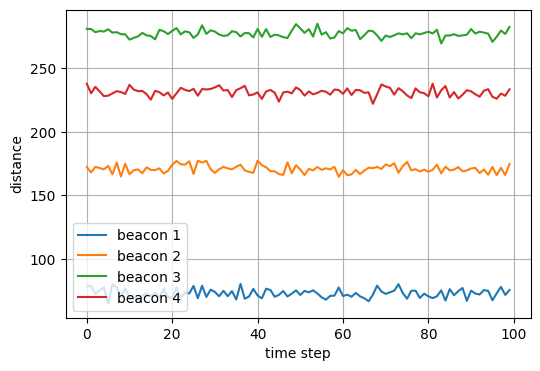

In [13]:
# @title
def meas_mdl(mu_cur):
   """
   Measurement model
      Inputs:
         mu_cur: current state mean (3,) [x_t, y_t, theta]
      Outputs:
         z: measurement vector (4,) [d_1, d_2, d_3, d_4]
   """
   posb = 120
   # beacon positions
   xy_beacon = np.array([[-posb, posb], [posb, posb], [posb, -posb], [-posb, -posb]])

   # *************************************************************
   # Measurement Model  ******************************************
   # *************************************************************
   # TODO: replace with correct state transition model
   z = np.zeros(4)
   x,y,_ = mu_cur

   for i, b in enumerate(xy_beacon):
    z[i] = np.sqrt( (x - b[0])**2 + (y - b[1])**2 )

   # *************************************************************
   # *************************************************************

   return z

# simulate noisy meas
def simulate_noisy_meas(mu_cur, R):
   """
   Simulate noisy measurement
      Inputs:
         mu_cur: current state mean (3,) [s_t, alpha, theta]
         R: measurement noise covariance (4x4)
      Outputs:
         z: measurement vector (4,) [d_1, d_2, d_3, d_4]
   """
   noise = np.random.multivariate_normal(np.zeros(4), R)

   # *****************************************************************
   # State Transition Model with Noise  ******************************
   # *****************************************************************
   # TODO: implement the measurement model with measurement noise (use noise above)
   z = meas_mdl(mu_cur) + noise

   # *****************************************************************
   # *****************************************************************
   return z

def simulate_measurements(pos, R, sim_num, seed=0):
   sim_num = 100
   z = np.zeros((4, sim_num))
   np.random.seed(seed)

   for i in range(sim_num):
      z[:, i] = simulate_noisy_meas(pos, R)

   return z

# plot the four measurements
def plot_measurements(z):
   sim_num = z.shape[1]
   plt.subplots(1, 1, figsize=(6, 4))
   plt.plot(np.arange(sim_num), z[0, :], label='beacon 1')
   plt.plot(np.arange(sim_num), z[1, :], label='beacon 2')
   plt.plot(np.arange(sim_num), z[2, :], label='beacon 3')
   plt.plot(np.arange(sim_num), z[3, :], label='beacon 4')
   plt.xlabel('time step')
   plt.ylabel('distance')
   plt.grid(True)
   plt.legend()
   plt.show()

# simulate noisy meas
pos = np.array([-50, 100, 0])
print(env)
z = simulate_measurements(pos, env['R'], sim_num=100)
plot_measurements(z)


In [4]:
# *** DO NOT MODIFY THE CODE BELOW ***
sol_34 = z.flatten()
print("@P3.4\n", *np.round(sol_34, 2))

@P3.4
 78.38 78.71 72.47 75.21 77.53 64.73 79.98 77.65 69.99 76.69 69.49 71.19 67.7 71.19 73.01 70.67 73.36 69.93 76.4 70.05 69.12 77.51 69.42 73.46 72.83 78.76 69.09 78.88 70.08 75.8 73.99 70.6 74.93 70.67 74.62 68.09 80.34 68.64 70.45 76.36 71.23 68.93 76.56 75.51 70.26 71.68 74.78 70.46 72.68 75.24 71.63 74.83 73.69 75.29 72.75 69.78 67.93 70.91 71.08 77.53 70.79 71.82 70.23 73.25 70.51 69.04 66.68 71.82 78.99 74.36 72.45 73.71 74.98 80.09 73.11 68.67 74.91 75.0 69.24 72.67 70.53 69.14 70.57 75.25 67.25 76.18 71.41 74.63 77.12 66.97 75.01 72.75 71.95 75.46 74.84 67.43 72.92 78.01 71.68 75.51 172.44 168.08 172.47 171.56 170.52 173.24 166.57 175.82 164.91 174.97 166.68 169.79 170.5 167.44 172.13 170.04 169.9 171.34 167.27 169.34 174.02 177.17 174.51 174.26 176.82 166.91 177.32 175.85 177.21 170.68 167.7 170.7 172.46 171.27 170.51 172.56 174.16 169.71 168.56 167.76 177.27 173.84 172.17 169.11 168.99 166.82 166.11 176.05 167.48 173.78 170.42 166.06 170.86 169.7 172.37 170.08 171.37 170.

### 3.5  Implemetating a State Transition Function [1 points]

Write a function called `get_F(mu_cur, u_cur)` which returns the linearized state transition matrix $F_t$ given the current state estimate `mu_cur` (numpy array of size (3,)) and control `u_cur` (numpy array of size (2,)). Check that it passes the autograder

***ANSWER***

[Submit your code to autograder]

In [5]:
def get_F(mu_cur, u_cur):
    """
    Compute the Jacobian of the state transition model
    Inputs:
        mu_cur: current state mean (3,) [s_t, alpha, theta]
        u_cur: current control input (2,) [s_t, alpha]
    Outputs:
        F: Jacobian matrix (3x3)
    """

    # *****************************************************************
    # Jacobian Computation  ******************************************
    # *****************************************************************
    # TODO: replace with correct Jacobian computation
    # F = np.zeros((3, 3))  # placeholder
    F = np.array([
      [1, 0, -u_cur[0] * np.sin(mu_cur[2])],
      [0, 1, u_cur[0] * np.cos(mu_cur[2])],
      [0, 0, 1]
  ])
    # *****************************************************************
    # *****************************************************************

    return F

In [6]:
# *** DO NOT MODIFY THE CODE BELOW ***
# For test (do not modify)
mu_test1 = np.array([10, 30, np.pi/4])
u_test1 = np.array([5, 0.1])
F_test1 = get_F(mu_test1, u_test1)

mu_test2 = np.array([20, -10, np.pi/6])
u_test2 = np.array([3, -0.2])
F_test2 = get_F(mu_test2, u_test2)

# for autograder
sol_35 = np.hstack([F_test1.flatten(), F_test2.flatten()])
print("@P3.5\n", *np.round(sol_35, 2))

@P3.5
 1.0 0.0 -3.54 0.0 1.0 3.54 0.0 0.0 1.0 1.0 0.0 -1.5 0.0 1.0 2.6 0.0 0.0 1.0


### 3.6 Implementing Measurement Matrix Function [1 points]

Write a function called `get_H(mu_cur)` which returns the linearized measurement matrix $H_t$ given the current (predicted) state estimate `mu_cur` (numpy array of (3,)). Check your function in autograder.

***ANSWER***

[Submit your code to autograder]

In [7]:
# @title
def get_H(mu_cur):
    """
    Compute the Jacobian of the measurement model
    Inputs:
        mu_cur: current state mean (3,) [s_t, alpha, theta]
    Outputs:
        H: Jacobian matrix (4x3)
    """
    # location of beacons
    xy_beacon = np.array([[-120, 120], [120, 120], [120, -120], [-120, -120]])

    # *****************************************************************
    # Jacobian Computation  ******************************************
    # *****************************************************************
    # TODO: replace with correct Jacobian computation

    x,y,_  = mu_cur

    d1 = np.sqrt((x - xy_beacon[0][0])**2 + (y - xy_beacon[0][1])**2)
    d2 = np.sqrt((x - xy_beacon[1][0])**2 + (y - xy_beacon[1][1])**2)
    d3 = np.sqrt((x - xy_beacon[2][0])**2 + (y - xy_beacon[2][1])**2)
    d4 = np.sqrt((x - xy_beacon[3][0])**2 + (y - xy_beacon[3][1])**2)


    H = np.array([
        [(x - xy_beacon[0][0]) / d1, (y - xy_beacon[0][1]) / d1, 0],
        [(x - xy_beacon[1][0]) / d2, (y - xy_beacon[1][1]) / d2, 0],
        [(x - xy_beacon[2][0]) / d3, (y - xy_beacon[2][1]) / d3, 0],
        [(x - xy_beacon[3][0]) / d4, (y - xy_beacon[3][1]) / d4, 0],
    ])

    # *****************************************************************
    # *****************************************************************

    return H

In [8]:
# *** DO NOT MODIFY THE CODE BELOW ***
# For test (do not modify)
mu_test1 = np.array([10, 30, np.pi/4])
H_test1 = get_H(mu_test1)
mu_test2 = np.array([20, -10, np.pi/6])
H_test2 = get_H(mu_test2)
# for autograder
sol_36 = np.hstack([H_test1.flatten(), H_test2.flatten()])

print("@P3.6\n", *np.round(sol_36, 2))

@P3.6
 0.82 -0.57 0.0 -0.77 -0.63 0.0 -0.59 0.81 0.0 0.65 0.76 0.0 0.73 -0.68 0.0 -0.61 -0.79 0.0 -0.67 0.74 0.0 0.79 0.62 0.0


### 3.7 Implementing Kalman Filter  [8 points]

Implement the extended Kalman filter.
Start with an initial state covariance of $P_0 = \text{diag}([25, 25, 1])$, and sample your initial state estimate $\hat{\mu}_0$ with respect to the true initial state $\mu_0$ and this initial covariance $P_0$.
In other words, $\hat{\mu}_0 \sim \mathcal{N}(\mu_0, P_0)$.
Similar to part (3), use a $\Delta t$ of 1 second.
For your filter, use the same $Q$ and $R$ matrices from the previous subparts.

Plot the estimated state trajectory with the true state trajectory for $100$ time steps.
Clearly mark the estimated initial point, the true initial point, and the beacon locations.
Ensure the x-axis corresponds to the x-position and the y-axis corresponds to the y-position of the state.
For this problem, you only need to run one simulation case.

Also, include the implemented code in your writeup.

*Hints:*
1.  Make sure you interpret the state orientation $\theta_t$ to be in **radians** (and, correspondingly, the angular rate $\alpha_t$ will be in radians per second).
2.  You will have to re-compute $F_t$ at every predict step since this matrix is linearized with respect to the state estimate $\mu_{t-1|t-1}$ and control $u_t$.
    Similarly, you will have to re-compute $H_t$ at every update step since this matrix is linearized with respect to the predicted state estimate $\mu_{t|t-1}$.
    See the definitions in the problem statement and parts (1) and (2) for more details.
    This is akin to how we recalculated the geometry matrix $G$ at each step when solving the navigation equation with Newton-Raphson (problem 1 on homework 2).
3.  Your simulated measurements at each time step have to be taken with respect to the *true* state (not the estimated state).
    You can use your `simulate_noisy_meas` function from part (4) for this.
4.  You may find it helpful to write the EKF predict and the EKF update steps in separate functions, e.g., `ekf_predict` and `ekf_update`.
    These functions can call the `get_F` and `get_H` functions you wrote in parts (5) and (6).
    After implementing these functions, you can continuously call the predict and update functions in your main for-loop to run your filter for 100 time steps.
5.  You may find it helpful to first generate the *true* trajectory as in part 3.
    Second, generate the simulated measurements $z_t$ *from the true trajectory*.
    Third, run the EKF using $z_t$ in the update step.

Note: In a real system, you could initialize from WLS with Newton-Raphson.
But, notice that the EKF will start tracking correctly within 2 timesteps, so the WLS initialization is not strictly necessary.

***ANSWER***

[Submit your code to autograder (6 points)]

[Provide a  plot of the estimated state trajectory overlayed on the true state trajectory based on the specifications in the problem (2 points)]

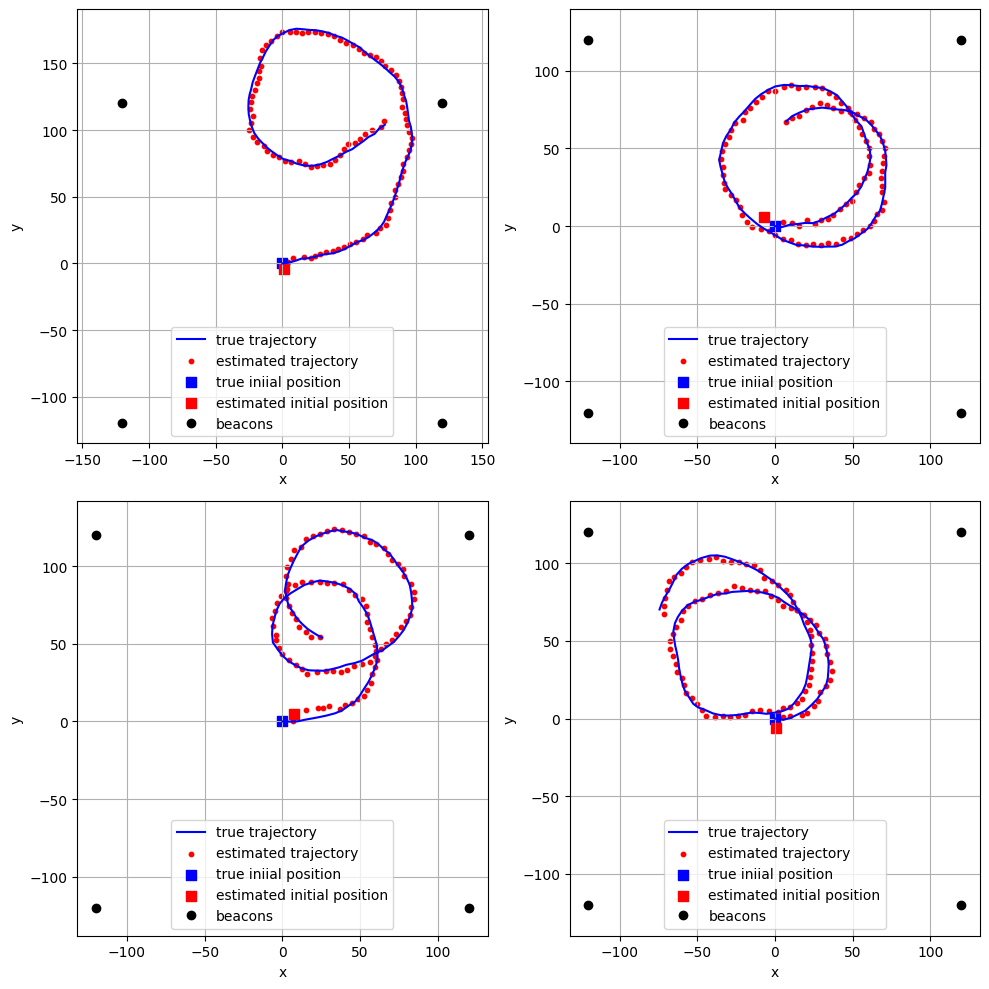

In [9]:
def ekf_predict(mu_hat, u_cur, P_hat, Q_ekf):
    """
    EKF Prediction step
    Inputs:
        mu_hat: current state estimate (3,)
        u_cur: current control input (2,)
        P_hat: current covariance estimate (3x3)
        Q_ekf: process noise covariance (3x3)
    Outputs:
        mu_bar: predicted state estimate (3,)
        P_bar: predicted covariance estimate (3x3)
    """

    # *****************************************************************
    # EKF Prediction Step  ********************************************
    # *****************************************************************
    # TODO: implement the EKF prediction step
    # *****************************************************************
    # *****************************************************************

    F = get_F(mu_hat, u_cur)
    mu_bar = state_trans_mdl(mu_hat, u_cur)

    P_bar = F @ P_hat @ F.T + Q_ekf

    return mu_bar, P_bar

def ekf_update(mu_bar, z_cur, P_bar, R_ekf):
    """
    EKF Update step
    Inputs:
        mu_bar: predicted state estimate (3,)
        z_cur: current measurement (4,)
        P_bar: predicted covariance estimate (3x3)
        R_ekf: measurement noise covariance (4x4)
    Outputs:
        mu_hat: updated state estimate (3,)
        P_hat: updated covariance estimate (3x3)
    """
    # *****************************************************************
    # EKF Update Step  ************************************************
    # *****************************************************************
    # TODO: implement the EKF update step
    # *****************************************************************
    # *****************************************************************

    # Innovation
    y_err = z_cur - meas_mdl(mu_bar)

    # Kalman Gain
    H = get_H(mu_bar)
    K = P_bar @ H.T @ np.linalg.inv(R_ekf + H @ P_bar @ H.T)

    # Updated state and cov.
    mu_hat = mu_bar + K @ y_err
    P_hat = (np.eye(3) - K @ H) @ P_bar

    return mu_hat, P_hat

def run_ekf(Q_ekf, R_ekf, u_cur, mu_true, z_true, P0):
    """
    Run EKF over the entire trajectory

    Inputs:
        Q_ekf: process noise covariance (3x3)
        R_ekf: measurement noise covariance (4x4)
        u_cur: current control input (2,)
        mu_true: true trajectory (3 x lent)
        z_true: measurements (4 x lent)
        P0: initial covariance (3x3)
    Outputs:
        mu_hat: estimated trajectory (3 x lent)
        P_hat: estimated covariance (3 x 3 x lent)
    """
    lent = mu_true.shape[1]
    mu_hat = np.zeros((3, lent))
    P_hat = np.zeros((3, 3, lent))

    # initial estiamte
    mu_hat[:, 0] = mu_true[:, 0] + np.random.multivariate_normal(np.zeros(3), P0)
    P_hat[:, :, 0] = P0

    for i in range(1, lent):
        # ****************************************************************
        # EKF over entire trajectory  ***********************************
        # ****************************************************************
        # TODO: implement the EKF over the entire trajectory
        mu_cur = mu_hat[:, i-1]
        P_cur = P_hat[:, :, i-1]

        mu_pre, P_pre = ekf_predict(mu_cur, u_cur, P_cur, Q_ekf)
        mu_post, P_post = ekf_update(mu_pre, z_true[:, i], P_pre, R_ekf)

        # mu_hat[:, i], P_hat[:, :, i] = ekf_predict

        mu_hat[:, i] = mu_post  # placeholder
        P_hat[:, :, i] = P_post  # placeholder
        # ****************************************************************
        # ****************************************************************

    return mu_hat, P_hat


def sim_true_traj_meas(mu0, u_cur, Q, R, lent, seed):
    """
    Simulate true (noisy) trajectory and measurements
    Inputs:
        mu0: initial state (3,)
        u_cur: current control input (2,)
        Q: process noise covariance (3x3)
        R: measurement noise covariance (4x4)
        lent: length of trajectory
    Outputs:
        mu_true: true trajectory (3 x lent)
        z_true: measurements (4 x lent)
    """
    mu_true = np.zeros((3, lent))
    z_true = np.zeros((4, lent))

    np.random.seed(seed)

    mu_true[:, 0] = mu0
    z_true[:, 0] = simulate_noisy_meas(mu0, R)

    for t in range(1, lent):
        mu_cur = mu_true[:, t - 1]
        # ****************************************************************
        # State and Measurement Simulation  ******************************
        # ****************************************************************
        # TODO: implement the simulation of true state and measurements
        # Hint: use 'simulate_noisy_state_trans' and 'simulate_noisy_meas'

        mu_next = simulate_noisy_state_trans(mu_cur, u_cur, Q)
        z_next = simulate_noisy_meas(mu_next, R)

        mu_true[:, t] = mu_next
        z_true[:, t] = z_next

        # ****************************************************************
        # ****************************************************************

    return mu_true, z_true

# plot the estimated trajectory with truth
def plot_ekf_traj(mu_true, mu_hat, z_true, ax):
    """
    Plot the EKF estimated trajectory with true trajectory
    Inputs:
        mu_true: true trajectory (3 x lent)
        mu_hat: estimated trajectory (3 x lent)
        z_true: measurements (4 x lent)
        ax: matplotlib axis
    Outputs:
        None
    """
    xy_beacon = np.array([[-120, 120], [120, 120], [120, -120], [-120, -120]])

    ax.plot(mu_true[0, :], mu_true[1, :], 'b-', label='true trajectory')
    ax.scatter(mu_hat[0, :], mu_hat[1, :], 10, color='red', label='estimated trajectory')
    ax.scatter(mu_true[0, 0], mu_true[1, 0], 50, marker='s', color='blue', label='true iniial position')
    ax.scatter(mu_hat[0, 0], mu_hat[1, 0], 50, marker='s', color='red', label='estimated initial position')
    # plot beacons
    for i in range(4):
        if i == 0:
            ax.plot(xy_beacon[i, 0], xy_beacon[i, 1], 'ko', label='beacons')
        else:
            ax.plot(xy_beacon[i, 0], xy_beacon[i, 1], 'ko')

    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.axis('equal')
    ax.grid(True)
    ax.legend(loc='lower center')

def run_ekf_nominal_sim(env, plot=True):
    """
    Run the EKF simulation and plot results
    Inputs:
        plot: whether to plot the results
    Outputs:
        mu_hat: estimated trajectory (3 x lent)
        P_hat: estimated covariance (3 x 3 x lent)
    """
    mu0 = env['mu0']
    u_cur = env['u_cur']
    Q = env['Q']
    R = env['R']
    lent = env['lent']

    # simulate true trajectory and measurements
    n_mc = 4  # number of Monte Carlo simulations
    P0 = np.diag(np.array([25, 25, 1]))
    Q_ekf = np.diag(np.array([0.1, 0.1, 0.01]))
    R_ekf = np.diag(np.array([10, 10, 10, 10]))

    if plot:
        fig, axs = plt.subplots(2, 2, figsize=(10, 10))

    for mci in range(n_mc):
        mu_true, z_true = sim_true_traj_meas(mu0, u_cur, Q, R, lent, seed=env['seed'] + 2*mci)
        mu_hat, P_hat = run_ekf(Q_ekf, R_ekf, u_cur, mu_true, z_true, P0)
        if plot:
            plot_ekf_traj(mu_true, mu_hat, z_true, axs[mci // 2, mci % 2])

    if plot:
        plt.tight_layout()
        plt.show()

    return mu_hat, P_hat


mu_hat, P_hat = run_ekf_nominal_sim(env, plot=True)


In [10]:
# *** DO NOT MODIFY THE CODE BELOW ***
# For test (do not modify)
sol_37 = np.hstack([mu_hat.flatten(), P_hat.flatten()])
print("@P3.7\n", *np.round(sol_37, 2))

@P3.7
 0.59 5.06 9.99 17.52 20.91 24.98 27.46 29.02 32.91 35.66 36.5 35.29 33.23 33.14 32.04 28.58 26.44 22.78 18.43 14.06 10.48 5.41 1.91 -2.44 -6.66 -11.66 -16.22 -21.29 -26.14 -31.47 -36.63 -41.71 -46.62 -51.16 -55.68 -59.05 -60.51 -63.59 -65.81 -67.42 -67.25 -65.72 -63.37 -62.83 -59.77 -58.31 -57.53 -53.3 -50.01 -47.02 -44.2 -38.71 -33.48 -28.67 -23.64 -18.91 -14.81 -9.7 -3.88 1.94 5.39 9.91 14.02 17.32 19.37 21.87 22.88 23.52 23.66 24.1 23.03 23.21 22.55 20.67 18.23 14.01 11.79 9.72 6.83 2.29 -2.06 -6.81 -9.69 -13.65 -18.6 -23.21 -28.31 -33.66 -37.74 -42.6 -48.49 -53.18 -57.19 -60.42 -65.04 -68.13 -69.53 -70.5 -71.2 -71.22 -6.24 0.8 1.88 2.45 3.83 7.88 11.64 17.23 21.08 25.05 30.7 36.41 41.41 46.76 51.37 55.37 59.96 63.66 66.73 69.59 71.33 72.51 76.37 79.18 81.89 82.29 82.77 83.9 85.35 82.15 80.52 79.54 76.82 75.46 72.78 69.49 63.36 59.08 54.68 49.84 44.99 40.17 35.28 30.16 25.98 21.61 16.31 13.16 9.61 5.69 1.97 1.29 1.81 0.79 1.88 2.44 4.76 5.69 4.62 4.49 7.09 7.47 10.15 12.94 17

### 3.8 Changing Parameters for EKF [8 points]

In the previous part, we assumed we had access to the true $Q$ and $R$ covariance matrices.
In other words, we gave our filter a perfect model of the process noise and measurement noise uncertainty.
What if there is a mismatch between the true noise covariances and those used by our filter?
Let's explore this further!

Let $Q_{\text{ekf}}$ represent the state transition covariance used by the EKF, and let $R_{\text{ekf}}$ represent the measurement covariance used by the EKF (which may be different from the *true* $Q$ and $R$ in your simulation).
Repeat part (7) again with the following changes to the filter covariance matrices:
1.  $Q_{\text{ekf}} = 0.01 Q$ and $R_{\text{ekf}} = R$
2.  $Q_{\text{ekf}} = Q$ and $R_{\text{ekf}} = 0.01 R$
3.  $Q_{\text{ekf}} = 0.01 Q$ and $R_{\text{ekf}} = 0.01 R$

Include your trajectory plot for each scaling scenario.
Explain what differences, if any, you observe from your plot in part (7), and explain why these differences (or lack thereof) occur.
**For fare comparison, make sure you use the same true trajectory and true, noisy measurements for all cases.**

*Note:* We are only changing the covariance matrices used by our EKF, denoted as $Q_\text{ekf}$ and $R_\text{ekf}$.

[^1]: Commonly, these dynamics are the system's equations of motion, as you would calculate for in a dynamics course like AA 242. It could also include the dynamics of a user clock (e.g., clock bias, drift, and drift rate), which is important in GPS timing applications like the power grid or stock market. Kalman Filter dynamics can be even more abstract, describing weather dynamics, economic markets, or biochemical processes.

[^2]: Unfortunately, we do not have time to derive the Kalman filter and extended Kalman filter in this course. For a proper derivation and a more complete analysis of Kalman filters and their many variants, please take AA 273 in the spring.

[^3]: In lecture 11, our measurement model directly worked with the position and velocity (e.g., from Newton-Raphson to solve WLS). In contrast, we are using individual ranging measurements. The lecture approach is called *loosely-coupled* filtering. The problem set approach is called *tightly-coupled* filtering.

***ANSWER***

[Provide three plots with different $Q_\text{ekf}$ and $R_\text{ekf}$ matrices (2 points)]

[Provide 2-3 sentence discussion on the differences you observe and an associated explanation for *each* of the three scenarios (6 points)]

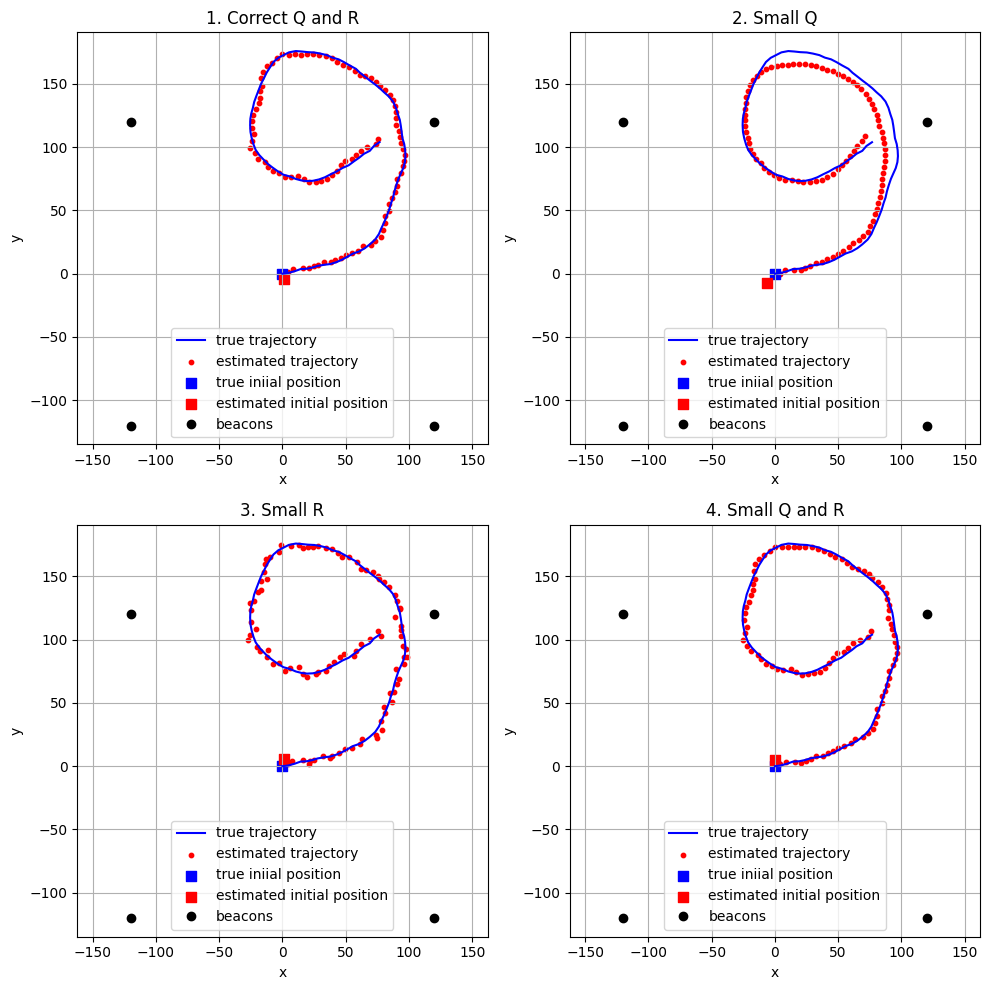

In [11]:
def run_ekf_QR_sims(env):
    """
    Run EKF simulations with different Q and R settings
    Inputs:
        env: environment dictionary
    Outputs:
        None
    """
    mu0 = env['mu0']
    u_cur = env['u_cur']
    Q = env['Q']
    R = env['R']
    lent = env['lent']

    P0 = np.diag(np.array([25, 25, 1]))
    fig, axs = plt.subplots(2, 2, figsize=(10, 10))
    sim_num = 4

    Q_ekfs = [Q, 0.01 * Q,  Q, 0.01 * Q]
    R_ekfs = [R, R, 0.01 * R, 0.01 * R]

    condition = list(range(sim_num))
    condition[0] = '1. Correct Q and R'
    condition[1] = '2. Small Q'
    condition[2] = '3. Small R'
    condition[3] = '4. Small Q and R'

    # use the same true traj meas for all cases
    mu_true, z_true = sim_true_traj_meas(mu0, u_cur, Q, R, lent, seed=0)

    for si in range(sim_num):
        Q_ekf = Q_ekfs[si]
        R_ekf = R_ekfs[si]
        mu_hat, P_hat = run_ekf(Q_ekf, R_ekf, u_cur, mu_true, z_true, P0)
        plot_ekf_traj(mu_true, mu_hat, z_true, axs[si // 2, si % 2])
        axs[si // 2, si % 2].set_title(condition[si])

    plt.tight_layout()
    plt.show()

run_ekf_QR_sims(env)

For the case where Q_ekf = 0.01Q, the EKF assumes that the prediction is "perfect" because it propogates the model with no noise in the system dynamics. Therefore, it does not weight the measurements as high (sort of equivalent to dead reckoning). It is precise (due to propogating system dynamics), but not accurate.

For the case with only small R, we are assuming that the measurements are perfect with no noise, which weights then more in the final position estimate, which is why it aligns very closely with the true trajectory, but is very noisy. That is, the position estimate is accurate, but not precise.

Finally, with small Q and R, seems somewhat close to the final trajectory, just like with the full Q and R. This could be explained by the Q and R being scaled by the same amount, so they are "weighted" the same in the final estimate. This also means that the filter has high confidence in both its model and system dynamics.